# Phase 3 (part 11): SHAP infrastructure for a neural model (MLP) and its validation

**What this is.** The first breadth-of-model notebook. It adds and *validates* a
model-agnostic SHAP path for a multi-layer perceptron (MLP), because the reviewer's
open question is whether the explanation-localization failure is **tree-specific**.
TreeSHAP (the validated `src.divergence.localization.shap_importance`) cannot run on
an MLP, so before any neural benchmark (notebooks 12/13) we must establish a SHAP
estimator for non-tree models and prove it is sound. This notebook does **not**
produce any benchmark result; it is purely infrastructure + a pre-registered
validation gate.

**Why a separate notebook.** A negative neural result is only credible if the
explainer behind it is known-good. We therefore validate the new path on a
**known-ground-truth** synthetic construction (the 07g logic): a decorrelated
planted relevant set that a working attribution method must recover.

**The model and the explainer (the two locked choices).**
- Model: scikit-learn `MLPClassifier`, hidden layers `(256,128,64)`, ReLU
  (the reviewer's recommended minimal neural architecture).
- Explainer: SHAP's model-agnostic `PermutationExplainer` by default (fast at this
  feature width), with a `KernelExplainer` fallback selectable via `SHAP_BACKEND`.
  Both are wrapped around `predict_proba(.)[:,1]` so the output matches the `(d,)`
  shape returned by the tree path and is a drop-in for downstream notebooks.

**Three validations.**
1. **Recovery.** On a decorrelated planted target, MLP-SHAP must recover it
   (precision@K high) with a model that actually learned the task (recall gate).
   This is the soundness check.
2. **Agreement.** On a random forest (where *both* the validated TreeSHAP path and
   the new agnostic path can run), the two importance rankings must agree
   (Spearman high). This shows the new harness reproduces the trusted one.
3. **Sensitivity (corroborating, not gating).** A 2-point redundancy smoke test
   ($\rho\in\{0,0.99\}$) checks the new path degrades in the expected direction.
   The full identifiability sweep is notebook 12's job; this is only a sanity check.

**Pre-registered gate (D028), committed before execution.**
- *MLP-SHAP-INFRA-VALID* iff recovery precision $\ge 0.80$ with valid recall
  ($\ge 0.70$) **AND** agnostic-vs-tree Spearman $\ge 0.80$ on the RF.
- Otherwise *MLP-SHAP-INFRA-INVALID* — fix the explainer (background size,
  `max_evals`, or switch backend) before running notebooks 12/13.

Numbering: 11, a Phase-3 generalization notebook (`05_phase3_generalization/`).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import shap
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from scipy.stats import spearmanr

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, precision_at_k, random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase3_11_mlp_shap_infra.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
COLOR = {'mlp': '#56B4E9', 'rf': '#E69F00', 'random': '#000000', 'rho0': '#56B4E9', 'rho99': '#D55E00'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='11_mlp_shap_infrastructure'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete. shap', shap.__version__)

Setup complete. shap 0.52.0


## 2. D028 — the neural-SHAP infrastructure decision and the pre-registered gate

In [3]:
log_decision(
    decision_id='D028',
    decision=(
        'Establish and validate a model-agnostic SHAP path for an MLP before any '
        'neural benchmark. Model = sklearn MLPClassifier hidden (256,128,64) ReLU. '
        'Explainer = shap.PermutationExplainer (default) or shap.KernelExplainer '
        '(fallback), both wrapped around predict_proba[:,1] and abs-averaged over an '
        'eval sample to return a (d,) global importance, matching the tree path so it '
        'is drop-in for notebooks 12/13. Validate on a known-GT synthetic construction '
        '(decorrelated planted relevant set, median-split linear labels): '
        '(1) RECOVERY -- MLP-SHAP precision@K on the planted set with valid recall; '
        '(2) AGREEMENT -- on an RF, Spearman between the validated TreeSHAP path and '
        'the new agnostic path on the same model; (3) SENSITIVITY (corroborating) -- '
        'a 2-point rho in {0,0.99} smoke test that the path degrades with external '
        'leakage. Pre-registered gate (committed before execution): '
        'MLP-SHAP-INFRA-VALID iff recovery precision >= 0.80 AND recall >= 0.70 AND '
        'agnostic-vs-tree Spearman >= 0.80; else INVALID.'
    ),
    rationale=(
        'A neural negative result (notebooks 12/13) is only credible if the explainer '
        'behind it is known-good. TreeSHAP cannot run on an MLP, so a model-agnostic '
        'estimator is required; it must be validated against a known ground truth and '
        'cross-checked against the already-trusted tree path on a model where both run. '
        'PermutationExplainer is chosen over KernelExplainer as the default for speed at '
        '42 features; KernelExplainer retained as a faithfulness fallback.'
    ),
    alternatives=(
        'DeepSHAP/GradientExplainer (rejected here: requires a torch/keras model; '
        'sklearn MLP is the reviewer-recommended minimal addition). KernelExplainer as '
        'default (rejected: slow at this width; kept as fallback). Skipping validation '
        'and trusting the explainer (rejected: defeats the purpose of a credible '
        'negative result).'
    ),
)

[DECISION LOGGED] D028


## 3. Configuration

Synthetic width matches UNSW (`N_FEATURES=42`) so the harness is exercised at the
real scale. The pre-registered thresholds live here, before any model is trained.

In [4]:
set_global_seed(42)

# --- MLP recipe (reviewer-recommended; reused verbatim by notebooks 12/13) ---
MLP_PARAMS = dict(hidden_layer_sizes=(256, 128, 64), activation='relu',
                  alpha=1e-4, max_iter=300, early_stopping=True,
                  n_iter_no_change=15, random_state=42)

# --- model-agnostic SHAP backend for non-tree models ---
SHAP_BACKEND = 'permutation'   # 'permutation' (default, fast) | 'kernel' (classic, slower)
SHAP_BG_N = 100                # background rows for the masker
SHAP_EVAL_N = 400              # eval rows for the global importance estimate
KERNEL_KMEANS = 50             # kmeans background size if backend == 'kernel'

# --- known-GT synthetic construction ---
N_ROWS = 12000
N_FEATURES = 42
REL_SIZE = 5
K_PRIMARY = REL_SIZE
SEEDS = [42, 1, 7]

# --- pre-registered validation thresholds (D028) ---
RECOVER_MIN = 0.80    # MLP-SHAP must recover the decorrelated planted target
RECALL_MIN = 0.70     # model must actually have learned the task
AGREE_MIN = 0.80      # agnostic-vs-tree Spearman on an RF
RHO_DROP_MIN = 0.20   # corroborating only: precision drop from rho=0 to rho=0.99

CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
print(f'features {N_FEATURES} | rel_size {REL_SIZE} | chance precision@{K_PRIMARY} = {CHANCE:.3f}')
print(f'backend = {SHAP_BACKEND} | gate: recover >= {RECOVER_MIN}, recall >= {RECALL_MIN}, '
      f'agree >= {AGREE_MIN}')

features 42 | rel_size 5 | chance precision@5 = 0.119
backend = permutation | gate: recover >= 0.8, recall >= 0.7, agree >= 0.8


## 4. The model-agnostic SHAP helper (drop-in for the tree path)

`agnostic_shap_importance` returns a `(d,)` global importance just like the tree
`shap_importance`, so `shap_importance_any` can dispatch by model type. After this
notebook validates it, paste the two functions below into
`src/divergence/localization.py` so notebooks 12/13 import them instead of
redefining.

In [5]:
def make_mlp(seed):
    return MLPClassifier(**{**MLP_PARAMS, 'random_state': seed})

def _proba1(model):
    # scalar output = P(class 1); gives shap_values of shape (n, d)
    return lambda X: model.predict_proba(np.asarray(X))[:, 1]

def agnostic_shap_importance(model, X_eval, X_bg, backend=SHAP_BACKEND,
                             eval_n=SHAP_EVAL_N, bg_n=SHAP_BG_N, seed=42):
    # Model-agnostic global SHAP importance (d,) for any predict_proba model.
    # Mirrors src.divergence.localization.shap_importance (abs-mean over samples),
    # so it is a drop-in for the tree path in the downstream benchmarks.
    rng = np.random.default_rng(seed)
    Xb = X_bg[rng.choice(len(X_bg), size=min(bg_n, len(X_bg)), replace=False)]
    Xe = X_eval[rng.choice(len(X_eval), size=min(eval_n, len(X_eval)), replace=False)]
    f = _proba1(model)
    if backend == 'kernel':
        expl = shap.KernelExplainer(f, shap.kmeans(Xb, min(bg_n, KERNEL_KMEANS)))
        sv = np.asarray(expl.shap_values(Xe, nsamples='auto', silent=True))
    else:
        expl = shap.PermutationExplainer(f, Xb)
        sv = np.asarray(expl(Xe, max_evals=2 * X_eval.shape[1] + 1, silent=True).values)
    return np.abs(sv).mean(axis=0)

# dispatch: trees -> validated TreeSHAP path; everything else -> agnostic path
try:
    from xgboost import XGBClassifier
    _XGB = (XGBClassifier,)
except Exception:
    _XGB = tuple()
_TREE = (RandomForestClassifier,) + _XGB

def shap_importance_any(model, X_eval, X_bg=None, **kw):
    if isinstance(model, _TREE):
        return shap_importance(model, X_eval)
    assert X_bg is not None, 'a non-tree model needs a background set X_bg'
    return agnostic_shap_importance(model, X_eval, X_bg, **kw)

print('Helpers ready:', make_mlp(42).__class__.__name__,
      '| dispatch trees ->', [t.__name__ for t in _TREE])

Helpers ready: MLPClassifier | dispatch trees -> ['RandomForestClassifier', 'XGBClassifier']


## 5. Known-ground-truth synthetic construction

Decorrelated Gaussian features with a planted linear relevant set $S$ (labels are a
median split of $X_S w$). With `rho>0`, each relevant feature is given a correlated
partner placed **outside** $S$, so the recovery target gains external leakage
$\approx \rho$ -- used only by the sensitivity smoke test.

In [6]:
def make_synthetic(n, d, rel_size, seed, rho=0.0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, d))
    S = np.sort(rng.choice(d, size=rel_size, replace=False))
    others = np.array([j for j in range(d) if j not in set(int(i) for i in S)])
    if rho > 0:
        partners = rng.choice(others, size=rel_size, replace=False)
        for i, p in zip(S, partners):
            X[:, p] = rho * X[:, i] + np.sqrt(1 - rho ** 2) * rng.standard_normal(n)
    w = rng.normal(size=rel_size)
    score = X[:, S] @ w
    y = (score > np.median(score)).astype(int)
    mu, sd = X.mean(0), X.std(0); sd[sd == 0] = 1.0
    Xz = (X - mu) / sd
    return Xz, y, set(int(i) for i in S)

# quick shape/label check
_Xz, _y, _gt = make_synthetic(N_ROWS, N_FEATURES, REL_SIZE, 42, rho=0.0)
print('X', _Xz.shape, '| label balance', round(float(_y.mean()), 3),
      '| |S|', len(_gt))

X (12000, 42) | label balance 0.5 | |S| 5


## 6. Validation 1 — recovery (the soundness check)

Decorrelated planted target, MLP trained per seed; MLP-SHAP must put the planted
features at the top (precision@K), with a model that actually learned the task
(recall gate). Random importance is the floor.

In [7]:
val1 = []
t0 = time.time()
for seed in SEEDS:
    Xz, y, gt = make_synthetic(N_ROWS, N_FEATURES, REL_SIZE, seed, rho=0.0)
    tr, ev = train_test_split(np.arange(len(y)), train_size=0.7, stratify=y, random_state=seed)
    mlp = make_mlp(seed).fit(Xz[tr], y[tr])
    rec = recall_score(y[ev], mlp.predict(Xz[ev]), zero_division=0)
    imp = shap_importance_any(mlp, Xz[ev], X_bg=Xz[tr], seed=seed)
    rnd = np.random.default_rng(seed).random(N_FEATURES)
    val1.append({'seed': seed, 'recall': float(rec),
                 'mlp_shap_p': precision_at_k(imp, gt, K_PRIMARY),
                 'random_p': precision_at_k(rnd, gt, K_PRIMARY)})
    print(f'  seed {seed} done ({time.time()-t0:.0f}s)')

val1_df = pd.DataFrame(val1)
print('\n' + val1_df.to_string(index=False))
mlp_p = float(val1_df['mlp_shap_p'].mean()); mlp_rec = float(val1_df['recall'].mean())
rnd_p = float(val1_df['random_p'].mean())
print(f'\nMLP-SHAP precision@{K_PRIMARY} = {mlp_p:.3f}  (recall {mlp_rec:.3f})')
print(f'random {rnd_p:.3f} | chance {CHANCE:.3f}')

  seed 42 done (28s)
  seed 1 done (47s)
  seed 7 done (70s)

 seed   recall  mlp_shap_p  random_p
   42 0.963333         1.0       0.0
    1 0.972222         1.0       0.2
    7 0.968889         1.0       0.0

MLP-SHAP precision@5 = 1.000  (recall 0.968)
random 0.067 | chance 0.119


## 7. Validation 2 — agreement with the trusted tree path

On a random forest, both the validated `shap_importance` (TreeSHAP) and the new
`agnostic_shap_importance` can run. If the new harness is correct, the two
importance vectors should rank features the same way (high Spearman).

In [8]:
agree = []
t0 = time.time()
for seed in SEEDS:
    Xz, y, gt = make_synthetic(N_ROWS, N_FEATURES, REL_SIZE, seed, rho=0.0)
    tr, ev = train_test_split(np.arange(len(y)), train_size=0.7, stratify=y, random_state=seed)
    rf = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(Xz[tr], y[tr])
    tree_imp = shap_importance(rf, Xz[ev][:SHAP_EVAL_N])                 # validated path
    agn_imp = agnostic_shap_importance(rf, Xz[ev], X_bg=Xz[tr], seed=seed)  # new path, same model
    rho_s = spearmanr(tree_imp, agn_imp).correlation
    agree.append({'seed': seed, 'spearman': float(rho_s) if rho_s == rho_s else 0.0,
                  'tree_p': precision_at_k(tree_imp, gt, K_PRIMARY),
                  'agnostic_p': precision_at_k(agn_imp, gt, K_PRIMARY)})
    print(f'  seed {seed} done ({time.time()-t0:.0f}s)')

agree_df = pd.DataFrame(agree)
print('\n' + agree_df.to_string(index=False))
agree_rho = float(agree_df['spearman'].mean())
print(f'\nagnostic-vs-tree Spearman = {agree_rho:.3f}  '
      f'(tree precision {agree_df["tree_p"].mean():.3f}, '
      f'agnostic {agree_df["agnostic_p"].mean():.3f})')

  seed 42 done (40s)
  seed 1 done (79s)
  seed 7 done (117s)

 seed  spearman  tree_p  agnostic_p
   42  0.904708     1.0         1.0
    1  0.881047     1.0         1.0
    7  0.889798     1.0         1.0

agnostic-vs-tree Spearman = 0.892  (tree precision 1.000, agnostic 1.000)


## 8. Validation 3 — sensitivity smoke test (corroborating, not gating)

Two points only, $\rho\in\{0,0.99\}$: MLP-SHAP recovery should fall as the planted
target gains a correlated partner outside $S$. This confirms the new path responds
to redundancy in the expected direction; the full sweep is notebook 12.

In [9]:
rho_check = {}
for rho in (0.0, 0.99):
    ps = []
    for seed in SEEDS:
        Xz, y, gt = make_synthetic(N_ROWS, N_FEATURES, REL_SIZE, seed, rho=rho)
        tr, ev = train_test_split(np.arange(len(y)), train_size=0.7, stratify=y, random_state=seed)
        mlp = make_mlp(seed).fit(Xz[tr], y[tr])
        imp = shap_importance_any(mlp, Xz[ev], X_bg=Xz[tr], seed=seed)
        ps.append(precision_at_k(imp, gt, K_PRIMARY))
    rho_check[rho] = float(np.mean(ps))
rho_drop = rho_check[0.0] - rho_check[0.99]
print('MLP-SHAP precision@%d:  rho=0.0 -> %.3f | rho=0.99 -> %.3f | drop = %+.3f'
      % (K_PRIMARY, rho_check[0.0], rho_check[0.99], rho_drop))

MLP-SHAP precision@5:  rho=0.0 -> 1.000 | rho=0.99 -> 0.600 | drop = +0.400


## 9. Figure

  saved: 11_mlp_shap_infrastructure.png / .pdf


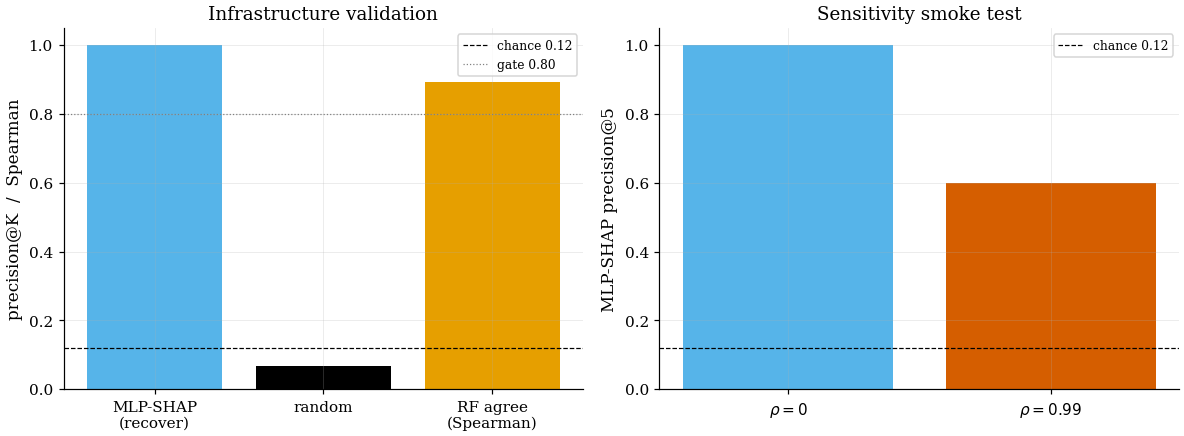

In [10]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel A: recovery + agreement
labels = ['MLP-SHAP\n(recover)', 'random', 'RF agree\n(Spearman)']
vals = [mlp_p, rnd_p, agree_rho]
cols = [COLOR['mlp'], COLOR['random'], COLOR['rf']]
axA.bar(range(3), vals, color=cols)
axA.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'chance {CHANCE:.2f}')
axA.axhline(RECOVER_MIN, ls=':', color='grey', lw=0.8, label=f'gate {RECOVER_MIN:.2f}')
axA.set_xticks(range(3)); axA.set_xticklabels(labels)
axA.set_ylim(0, 1.05); axA.set_ylabel('precision@K  /  Spearman')
axA.set_title('Infrastructure validation'); axA.legend(fontsize=8)

# Panel B: sensitivity smoke test
axB.bar([0, 1], [rho_check[0.0], rho_check[0.99]],
        color=[COLOR['rho0'], COLOR['rho99']])
axB.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'chance {CHANCE:.2f}')
axB.set_xticks([0, 1]); axB.set_xticklabels([r'$\rho=0$', r'$\rho=0.99$'])
axB.set_ylim(0, 1.05); axB.set_ylabel(f'MLP-SHAP precision@{K_PRIMARY}')
axB.set_title('Sensitivity smoke test'); axB.legend(fontsize=8)

fig.tight_layout(); save_figure(fig, '11_mlp_shap_infrastructure'); plt.show()

## 10. Pre-registered verdict (D028)

In [11]:
recover_ok = (mlp_p >= RECOVER_MIN) and (mlp_rec >= RECALL_MIN)
agree_ok = agree_rho >= AGREE_MIN
rho_ok = rho_drop >= RHO_DROP_MIN          # corroborating only
infra_valid = recover_ok and agree_ok
verdict = 'MLP-SHAP-INFRA-VALID' if infra_valid else 'MLP-SHAP-INFRA-INVALID'

print('=' * 70)
print('MLP-SHAP INFRASTRUCTURE VALIDATION (D028)')
print('=' * 70)
print(f'  backend: {SHAP_BACKEND} | features {N_FEATURES} | seeds {SEEDS}')
print(f'  recovery : MLP-SHAP precision@{K_PRIMARY} {mlp_p:.3f} '
      f'(>= {RECOVER_MIN}? {mlp_p >= RECOVER_MIN}) | recall {mlp_rec:.3f} '
      f'(>= {RECALL_MIN}? {mlp_rec >= RECALL_MIN})')
print(f'  agreement: agnostic-vs-tree Spearman {agree_rho:.3f} '
      f'(>= {AGREE_MIN}? {agree_ok})')
print(f'  sensitivity (corroborating): rho drop {rho_drop:+.3f} '
      f'(>= {RHO_DROP_MIN}? {rho_ok})')
print('-' * 70)
print(f'--> VERDICT: {verdict}')
if infra_valid:
    print('   The MLP-SHAP path recovers a known decorrelated target and reproduces the')
    print('   trusted tree path. It is safe to use in notebooks 12 (identifiability sweep)')
    print('   and 13 (UNSW drift-localization benchmark).')
else:
    print('   Do NOT proceed to 12/13. Adjust SHAP_BG_N / SHAP_EVAL_N / max_evals, or set')
    print('   SHAP_BACKEND = "kernel", and re-run until both gates pass.')

MLP-SHAP INFRASTRUCTURE VALIDATION (D028)
  backend: permutation | features 42 | seeds [42, 1, 7]
  recovery : MLP-SHAP precision@5 1.000 (>= 0.8? True) | recall 0.968 (>= 0.7? True)
  agreement: agnostic-vs-tree Spearman 0.892 (>= 0.8? True)
  sensitivity (corroborating): rho drop +0.400 (>= 0.2? True)
----------------------------------------------------------------------
--> VERDICT: MLP-SHAP-INFRA-VALID
   The MLP-SHAP path recovers a known decorrelated target and reproduces the
   trusted tree path. It is safe to use in notebooks 12 (identifiability sweep)
   and 13 (UNSW drift-localization benchmark).


In [12]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'purpose': 'validate a model-agnostic SHAP path for the MLP before neural benchmarks',
    'model': 'sklearn MLPClassifier (256,128,64) relu',
    'shap_backend': SHAP_BACKEND, 'shap_bg_n': SHAP_BG_N, 'shap_eval_n': SHAP_EVAL_N,
    'n_features': N_FEATURES, 'rel_size': REL_SIZE, 'seeds': SEEDS, 'chance': CHANCE,
    'recovery': {'mlp_shap_precision': mlp_p, 'recall': mlp_rec, 'random_precision': rnd_p},
    'agreement_spearman_vs_tree': agree_rho,
    'sensitivity_smoke': {'rho_0': rho_check[0.0], 'rho_099': rho_check[0.99], 'drop': rho_drop},
    'gate': {'recover_min': RECOVER_MIN, 'recall_min': RECALL_MIN, 'agree_min': AGREE_MIN},
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F016',
    title='MLP-SHAP infrastructure validated (model-agnostic explainer for the neural breadth phase)',
    context='05_phase3_generalization/11_mlp_shap_infrastructure',
    what_we_did=(
        'Added a model-agnostic SHAP path (PermutationExplainer default, KernelExplainer '
        'fallback) for an sklearn MLPClassifier (256,128,64), returning a (d,) global '
        'importance drop-in for the tree path. Validated on a known-GT synthetic '
        'construction: recovery of a decorrelated planted target with a recall gate, '
        'agreement with the trusted TreeSHAP path on an RF, and a 2-point redundancy '
        'sensitivity smoke test. D028.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Recovery MLP-SHAP precision@%d = %.3f (recall %.3f, '
        'random %.3f, chance %.3f); agnostic-vs-tree Spearman = %.3f; sensitivity drop '
        'rho 0->0.99 = %+.3f.'
        % (K_PRIMARY, mlp_p, mlp_rec, rnd_p, CHANCE, agree_rho, rho_drop)
    ),
    why_it_matters=(
        'A neural negative result is only credible if the explainer is known-good. This '
        'establishes and validates the MLP-SHAP estimator used by notebooks 12 and 13, '
        'so the cross-model claim (the failure is not tree-specific) rests on a sound '
        'attribution method rather than an unchecked one.'
    ),
)
print('F016 logged.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase3_11_mlp_shap_infra.json
[FINDING LOGGED] F016: MLP-SHAP infrastructure validated (model-agnostic explainer for the neural breadth phase)
F016 logged.


## 11. What this settles, and what is next

- If **MLP-SHAP-INFRA-VALID**: the neural attribution path is sound. Paste
  `agnostic_shap_importance` and `shap_importance_any` into
  `src/divergence/localization.py`, then proceed to **notebook 12**
  (`12_mlp_identifiability_sweep.ipynb`) — the synthetic $\rho$-sweep that extends
  contribution **C3 / Fig. 5** to the MLP — and **notebook 13**
  (`13_mlp_unsw_benchmark.ipynb`) — the UNSW drift-localization benchmark (the 10b
  analog) that extends **C1/C2** to the MLP.
- If **INVALID**: do not proceed; tune the explainer settings or switch backend and
  re-run this notebook until both gates pass.

Record the call by hand:

In [13]:
# add_journal_entry(
#     title='Notebook 11 MLP-SHAP infrastructure validation',
#     body='...the chosen model (MLPClassifier 256,128,64) and explainer '
#          '(PermutationExplainer default / KernelExplainer fallback), the recovery + '
#          'agreement gates, the verdict, and that 12/13 may now use the validated path.',
# )